# Federated Learning for Heart Disease Prediction
# Flower + PyTorch + FedAvg

## Part 1 - Install Required Libraries, Import Packages, Load Client Datasets

In [1]:
# Install required libraries when running in a fresh environment.
# If everything is already installed, this cell will finish quickly.
%pip install -q "flwr[simulation]" torch torchvision torchaudio scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import importlib.util
import os
import random
import warnings

import flwr as fl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from collections import OrderedDict
from flwr.common import ndarrays_to_parameters
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", DEVICE)

Using Device: cpu


In [4]:
NUM_CLIENTS = 4
NUM_ROUNDS = 10
LOCAL_EPOCHS = 5
BATCH_SIZE = 32
LEARNING_RATE = 0.001
TEST_SIZE = 0.20
RANDOM_STATE = 42

CLIENT_DATA_DIR = "data/clients"
CLIENT_FILES = [
    "hospital_a.csv",
    "hospital_b.csv",
    "hospital_c.csv",
    "hospital_d.csv",
]

RESULTS_DIR = "results"
MODEL_SAVE_PATH = "models"
GLOBAL_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "global_model.pth")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

In [5]:
client_paths = [os.path.join(CLIENT_DATA_DIR, filename) for filename in CLIENT_FILES]

client_datasets = []
for path in client_paths:
    df = pd.read_csv(path)
    client_datasets.append(df)
    print(f"{os.path.basename(path)}: {df.shape}")

summary_path = os.path.join(RESULTS_DIR, "client_summary.csv")
if os.path.exists(summary_path):
    client_summary = pd.read_csv(summary_path)
    display(client_summary)

hospital_a.csv: (303, 14)
hospital_b.csv: (294, 14)
hospital_c.csv: (123, 14)
hospital_d.csv: (200, 14)


,Client,Rows,Disease %
0,hospital_a.csv,303,45.87
1,hospital_b.csv,294,36.05
2,hospital_c.csv,123,93.50
3,hospital_d.csv,200,74.50


## Part 2 - Reusable Data Loader, Train/Test Split, StandardScaler, PyTorch DataLoader

In [6]:
class HeartDiseaseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False):
    dataset = HeartDiseaseDataset(X, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def prepare_client_loaders(client_frames, feature_columns, target_column="target"):
    client_splits = []
    all_train_features = []

    for client_name, df in zip(CLIENT_FILES, client_frames):
        X = df[feature_columns].astype(np.float32).values
        y = df[target_column].astype(np.float32).values

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y,
        )

        client_splits.append(
            {
                "client_name": client_name.replace(".csv", ""),
                "X_train": X_train,
                "X_test": X_test,
                "y_train": y_train,
                "y_test": y_test,
            }
        )
        all_train_features.append(X_train)

    scaler = StandardScaler()
    scaler.fit(np.vstack(all_train_features))

    client_loaders = []
    for split in client_splits:
        X_train_scaled = scaler.transform(split["X_train"]).astype(np.float32)
        X_test_scaled = scaler.transform(split["X_test"]).astype(np.float32)

        client_loaders.append(
            {
                "client_name": split["client_name"],
                "train_loader": make_loader(X_train_scaled, split["y_train"], shuffle=True),
                "test_loader": make_loader(X_test_scaled, split["y_test"], shuffle=False),
                "num_train_examples": len(split["y_train"]),
                "num_test_examples": len(split["y_test"]),
            }
        )

    return client_loaders, scaler

In [7]:
target_column = "target"
feature_columns = [col for col in client_datasets[0].columns if col != target_column]
input_dim = len(feature_columns)

client_loaders, scaler = prepare_client_loaders(
    client_datasets,
    feature_columns=feature_columns,
    target_column=target_column,
)

print(f"Input features: {input_dim}")
for loader_info in client_loaders:
    print(
        f"{loader_info['client_name']}: "
        f"train={loader_info['num_train_examples']}, "
        f"test={loader_info['num_test_examples']}"
    )

Input features: 13
hospital_a: train=242, test=61
hospital_b: train=235, test=59
hospital_c: train=98, test=25
hospital_d: train=160, test=40


## Part 3 - Build the HeartDiseaseNet Neural Network

In [8]:
class HeartDiseaseNet(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 32),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.network(x)


global_model = HeartDiseaseNet(input_dim).to(DEVICE)
print(global_model)

HeartDiseaseNet(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Part 4 - Local Training Function and Local Evaluation Function

In [9]:
def train_local_model(model, train_loader, epochs=LOCAL_EPOCHS):
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    total_loss = 0.0
    total_examples = 0

    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = X_batch.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

    return total_loss / total_examples


def predict(model, loader):
    model.eval()
    probabilities = []
    labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(DEVICE))
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            probabilities.extend(probs)
            labels.extend(y_batch.numpy().ravel())

    return np.array(labels), np.array(probabilities)


def evaluate_on_loader(model, loader):
    y_true, y_prob = predict(model, loader)
    y_pred = (y_prob >= 0.5).astype(int)
    criterion = nn.BCEWithLogitsLoss()

    loss_values = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logits = model(X_batch.to(DEVICE))
            loss = criterion(logits, y_batch.to(DEVICE))
            loss_values.append(loss.item() * X_batch.size(0))

    return {
        "loss": sum(loss_values) / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }


def evaluate_global_model(model, loaders):
    y_true_parts = []
    y_prob_parts = []

    for loader_info in loaders:
        y_true, y_prob = predict(model, loader_info["test_loader"])
        y_true_parts.append(y_true)
        y_prob_parts.append(y_prob)

    y_true = np.concatenate(y_true_parts)
    y_prob = np.concatenate(y_prob_parts)
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, zero_division=0),
    }

## Part 5 - Flower NumPyClient

In [10]:
def get_model_parameters(model):
    return [value.detach().cpu().numpy().copy() for value in model.state_dict().values()]


def set_model_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict(
        {
            key: torch.tensor(value, dtype=model.state_dict()[key].dtype)
            for key, value in params_dict
        }
    )
    model.load_state_dict(state_dict, strict=True)


class HeartDiseaseClient(fl.client.NumPyClient):
    def __init__(self, client_id, train_loader, test_loader):
        self.client_id = client_id
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.model = HeartDiseaseNet(input_dim).to(DEVICE)

    def get_parameters(self, config):
        return get_model_parameters(self.model)

    def fit(self, parameters, config):
        set_model_parameters(self.model, parameters)
        loss = train_local_model(
            self.model,
            self.train_loader,
            epochs=int(config.get("local_epochs", LOCAL_EPOCHS)),
        )
        return get_model_parameters(self.model), len(self.train_loader.dataset), {"loss": float(loss)}

    def evaluate(self, parameters, config):
        set_model_parameters(self.model, parameters)
        metrics = evaluate_on_loader(self.model, self.test_loader)
        return (
            float(metrics["loss"]),
            len(self.test_loader.dataset),
            {
                "accuracy": float(metrics["accuracy"]),
                "precision": float(metrics["precision"]),
                "recall": float(metrics["recall"]),
                "f1": float(metrics["f1"]),
                "roc_auc": float(metrics["roc_auc"]),
            },
        )


def client_fn(cid):
    loader_info = client_loaders[int(cid)]
    return HeartDiseaseClient(
        client_id=cid,
        train_loader=loader_info["train_loader"],
        test_loader=loader_info["test_loader"],
    ).to_client()

## Part 6 - Configure the FedAvg Server

In [11]:
history = []


def weighted_average(metrics):
    total_examples = sum(num_examples for num_examples, _ in metrics)
    return {
        key: sum(num_examples * metric_values[key] for num_examples, metric_values in metrics) / total_examples
        for key in metrics[0][1]
    }


def average_parameters(client_results):
    total_examples = sum(num_examples for _, num_examples in client_results)
    averaged_parameters = []

    for parameter_group in zip(*(parameters for parameters, _ in client_results)):
        averaged_parameters.append(
            sum(parameter * num_examples for parameter, (_, num_examples) in zip(parameter_group, client_results))
            / total_examples
        )

    return averaged_parameters


def fit_config(server_round):
    return {"local_epochs": LOCAL_EPOCHS}


def server_evaluate(server_round, parameters, config):
    set_model_parameters(global_model, parameters)
    metrics = evaluate_global_model(global_model, client_loaders)
    loss = 1.0 - metrics["accuracy"]

    if server_round > 0:
        history.append(
            {
                "round": server_round,
                "loss": loss,
                "accuracy": metrics["accuracy"],
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
                "roc_auc": metrics["roc_auc"],
            }
        )

    return loss, {
        "accuracy": float(metrics["accuracy"]),
        "precision": float(metrics["precision"]),
        "recall": float(metrics["recall"]),
        "f1": float(metrics["f1"]),
        "roc_auc": float(metrics["roc_auc"]),
    }


initial_model_parameters = get_model_parameters(global_model)
initial_parameters = ndarrays_to_parameters(initial_model_parameters)

strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=NUM_CLIENTS,
    min_evaluate_clients=NUM_CLIENTS,
    min_available_clients=NUM_CLIENTS,
    initial_parameters=initial_parameters,
    on_fit_config_fn=fit_config,
    evaluate_fn=server_evaluate,
    fit_metrics_aggregation_fn=weighted_average,
    evaluate_metrics_aggregation_fn=weighted_average,
)

## Part 7 - Start Federated Training

In [12]:
if importlib.util.find_spec("ray") is not None:
    simulation_history = fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=NUM_ROUNDS),
        strategy=strategy,
        client_resources={"num_cpus": 1, "num_gpus": 0.0},
    )
else:
    print("Ray is not installed, so running an in-process FedAvg simulation with Flower NumPyClients.")
    global_parameters = initial_model_parameters

    for server_round in range(1, NUM_ROUNDS + 1):
        client_results = []
        client_metrics = []

        for cid in range(NUM_CLIENTS):
            flower_client = HeartDiseaseClient(
                client_id=str(cid),
                train_loader=client_loaders[cid]["train_loader"],
                test_loader=client_loaders[cid]["test_loader"],
            )

            updated_parameters, num_examples, fit_metrics = flower_client.fit(
                global_parameters,
                fit_config(server_round),
            )
            client_results.append((updated_parameters, num_examples))
            client_metrics.append((num_examples, fit_metrics))

        global_parameters = average_parameters(client_results)
        server_loss, server_metrics = server_evaluate(server_round, global_parameters, {})

        print(
            f"Round {server_round:02d} | "
            f"loss={server_loss:.4f} | "
            f"acc={server_metrics['accuracy']:.4f} | "
            f"f1={server_metrics['f1']:.4f} | "
            f"auc={server_metrics['roc_auc']:.4f}"
        )

history_df = pd.DataFrame(history)
history_df

Round 01 | loss=0.6568 | accuracy=0.7730 | f1=0.7766 | roc_auc=0.8384
Round 02 | loss=0.6086 | accuracy=0.8162 | f1=0.8333 | roc_auc=0.8755


Round 03 | loss=0.5457 | accuracy=0.8432 | f1=0.8612 | roc_auc=0.8874
Round 04 | loss=0.4828 | accuracy=0.8378 | f1=0.8571 | roc_auc=0.8945


Round 05 | loss=0.4420 | accuracy=0.8432 | f1=0.8626 | roc_auc=0.8969
Round 06 | loss=0.4240 | accuracy=0.8432 | f1=0.8626 | roc_auc=0.8998


Round 07 | loss=0.4082 | accuracy=0.8486 | f1=0.8679 | roc_auc=0.9005
Round 08 | loss=0.4027 | accuracy=0.8541 | f1=0.8732 | roc_auc=0.9015


Round 09 | loss=0.3977 | accuracy=0.8486 | f1=0.8692 | roc_auc=0.9020


Round 10 | loss=0.3924 | accuracy=0.8432 | f1=0.8651 | roc_auc=0.9014


,round,loss,accuracy,precision,recall,f1,roc_auc
0,1,0.656793,0.772973,0.848837,0.715686,0.776596,0.838412
1,2,0.608564,0.816216,0.833333,0.833333,0.833333,0.875502
2,3,0.545660,0.843243,0.841121,0.882353,0.861244,0.887432
3,4,0.482780,0.837838,0.833333,0.882353,0.857143,0.894519
4,5,0.441968,0.843243,0.834862,0.892157,0.862559,0.896882
5,6,0.423972,0.843243,0.834862,0.892157,0.862559,0.899835
6,7,0.408178,0.848649,0.836364,0.901961,0.867925,0.900543
7,8,0.402745,0.854054,0.837838,0.911765,0.873239,0.901488
8,9,0.397749,0.848649,0.830357,0.911765,0.869159,0.901961
9,10,0.392449,0.843243,0.823009,0.911765,0.865116,0.901370


## Part 8 - Evaluate the Global Model, Save global_model.pth, Plot Training Accuracy/Loss

In [13]:
final_metrics = evaluate_global_model(global_model, client_loaders)

print("Final Global Model Performance")
print(f"Accuracy : {final_metrics['accuracy']:.4f}")
print(f"Precision: {final_metrics['precision']:.4f}")
print(f"Recall   : {final_metrics['recall']:.4f}")
print(f"F1-score : {final_metrics['f1']:.4f}")
print(f"ROC-AUC  : {final_metrics['roc_auc']:.4f}")
print("\nConfusion Matrix:")
print(final_metrics["confusion_matrix"])
print("\nClassification Report:")
print(final_metrics["classification_report"])

Final Global Model Performance
Accuracy : 0.8432
Precision: 0.8230
Recall   : 0.9118
F1-score : 0.8651
ROC-AUC  : 0.9014

Confusion Matrix:
[[63 20]
 [ 9 93]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.76      0.81        83
         1.0       0.82      0.91      0.87       102

    accuracy                           0.84       185
   macro avg       0.85      0.84      0.84       185
weighted avg       0.85      0.84      0.84       185



In [14]:
results_path = os.path.join(RESULTS_DIR, "federated_results.csv")
history_path = os.path.join(RESULTS_DIR, "federated_training_history.csv")

summary_df = pd.DataFrame(
    [
        {
            "model": "Flower FedAvg HeartDiseaseNet",
            "rounds": NUM_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "accuracy": final_metrics["accuracy"],
            "precision": final_metrics["precision"],
            "recall": final_metrics["recall"],
            "f1": final_metrics["f1"],
            "roc_auc": final_metrics["roc_auc"],
        }
    ]
)

history_df.to_csv(history_path, index=False)
summary_df.to_csv(results_path, index=False)

torch.save(
    {
        "model_state_dict": global_model.state_dict(),
        "feature_columns": feature_columns,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "config": {
            "num_rounds": NUM_ROUNDS,
            "local_epochs": LOCAL_EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
        },
        "metrics": summary_df.iloc[0].to_dict(),
    },
    GLOBAL_MODEL_PATH,
)

print(f"Saved summary: {results_path}")
print(f"Saved history: {history_path}")
print(f"Saved model: {GLOBAL_MODEL_PATH}")
summary_df

Saved summary: results\federated_results.csv
Saved history: results\federated_training_history.csv
Saved model: models\global_model.pth


,model,rounds,local_epochs,accuracy,precision,recall,f1,roc_auc
0,Flower FedAvg HeartDiseaseNet,10,5,0.843243,0.823009,0.911765,0.865116,0.90137


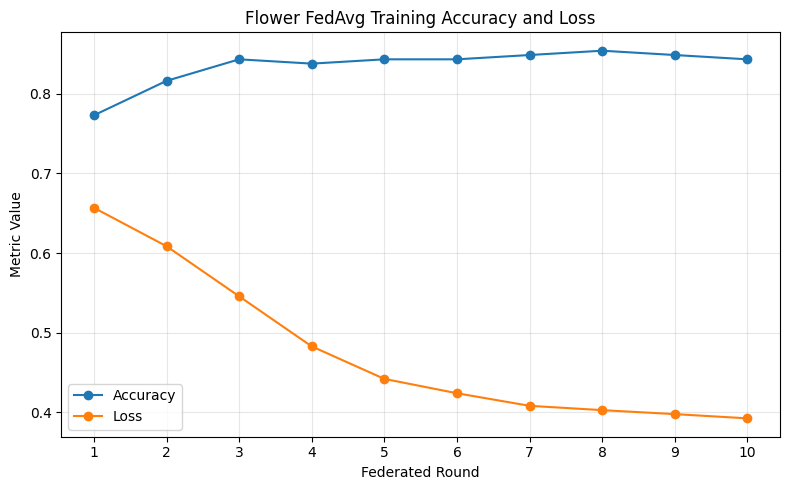

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["round"], history_df["accuracy"], marker="o", label="Accuracy")
plt.plot(history_df["round"], history_df["loss"], marker="o", label="Loss")
plt.xlabel("Federated Round")
plt.ylabel("Metric Value")
plt.title("Flower FedAvg Training Accuracy and Loss")
plt.xticks(history_df["round"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()